# Portfolio Analysis Project Assignment


In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [24]:
selected_seven = ["META", "GOOGL", "DIS", "BBY", "AAL","CAT", "WRB"]

I chose the following diverse set of stocks:
| Stock | Company Name | Industry |
| :--- | :--- | :--- |
| **META** | Meta Platforms, Inc. | Interactive Media & Services |
| **GOOGL** | Alphabet Inc. | Interactive Media & Services |
| **DIS** | The Walt Disney Company | Entertainment |
| **BBY** | Best Buy Co., Inc. | Specialty Retail |
| **AAL** | American Airlines Group Inc. | Passenger Airlines |
| **CAT** | Caterpillar Inc. | Machinery |
| **WRB** | W. R. Berkley Corporation | Insurance |

In [25]:

# get the close price data for `selected_seven` stocks from 2016-03-24 to 2026-03-24
stocks = yf.download(selected_seven, start="2016-03-24", end="2026-03-24")["Close"].dropna(how="all").dropna(axis=1)
stocks.columns = selected_seven 
stocks.head()

[*********************100%***********************]  7 of 7 completed


,META,GOOGL,DIS,BBY,AAL,CAT,WRB
Date,,,,,,,
2016-03-24,38.809242,21.907787,59.414082,89.611252,37.432625,112.169762,12.713231
2016-03-28,39.202133,21.970802,59.437767,90.413162,37.355267,112.804779,12.859603
2016-03-29,39.623768,22.194847,59.982262,90.477692,37.980591,115.235687,13.017779
2016-03-30,39.652512,22.103828,60.376823,91.168999,38.102081,113.806900,13.256228
2016-03-31,39.297947,22.712959,60.400517,91.537689,37.832317,113.211571,13.268031


- `stocks` - daily close-price DataFrame for the 7 selected tickers.
- `market_index` - daily close-price DataFrame for `SPY`, `IWM`, and `DIA.`

In [26]:
# SPY, IWM, DIA data pull
market_etfs = ["SPY", "IWM", "DIA"]
market_index = yf.download(market_etfs, start="2016-03-24", end="2026-03-24")["Close"].dropna()
market_index.head()

[*********************100%***********************]  3 of 3 completed


Ticker,DIA,IWM,SPY
Date,,,
2016-03-24,143.486038,94.282501,172.568604
2016-03-28,143.633652,94.396851,172.670547
2016-03-29,144.412964,97.017754,174.267715
2016-03-30,145.085464,97.026535,175.032440
2016-03-31,144.880447,97.299202,174.607681


## Part 1 - Comparison of Stocks against the market ETFs

We create a new DataFrame `stock_vs_market` which will store how each stock compare against market ETFs.

In [27]:
# dataframe `stock_vs_market` to compare individual stock to market ETFs (SPY, IWM, DIA)

stock_vs_market = pd.DataFrame({

    # 1a. portfolio weight: equal-weighted portfolio, so each stock has the same weight, which is `1/len(selected_seven)`.
    "portfolio_weight": [1/len(selected_seven)] * len(selected_seven),
    
    # 1b. annualized volatility: calculated using the standard deviation of daily returns over the trailing 
    # 3 months (63 trading days), and then annualized by multiplying by the square root of 252 (the number of trading days in a year).
    # using square-root-of-time rule to annualize volatility: `252**0.5` is the same as `sqrt(252)`, where 252 is the number of trading days 
    # in a year.
    # Source: NumPy documentation — np.sqrt() returns the square root.
    # Finance convention: annualized volatility = daily return standard deviation * sqrt(252 trading days).
    # https://numpy.org/doc/2.1/reference/generated/numpy.sqrt.html 
    "annualized_volatility": stocks.tail(63).pct_change().std() * (252**0.5) # trailing 3 months volatility

})

# setting stock tickers as index for `stock_vs_market` dataframe
stock_vs_market.index = selected_seven

In [28]:
stock_vs_market.sort_values("annualized_volatility", ascending=False)

,portfolio_weight,annualized_volatility
META,0.142857,0.480299
DIS,0.142857,0.355100
GOOGL,0.142857,0.354384
CAT,0.142857,0.348677
BBY,0.142857,0.282701
AAL,0.142857,0.208616
WRB,0.142857,0.205110


Equal weight was assigned to each of the seven stocks. `AAL` and `WRB` are the least volatile stocks as per the annualized trailing 3-months data both of their annualized volatilities are about `0.21`. `META` tops the list with a volatility of `0.48`.

In [29]:
# beta calculation: trailing 12 months (approx. 252 trading days)
# Align dates before computing cov/var.
trailing_days = 252
stocks_12mo = stocks.tail(trailing_days)
market_12m = market_index.tail(trailing_days)
stock_ret_12m = stocks_12mo.pct_change()

# 1d, e, f. beta calculation for each stock against each market index (SPY, IWM, DIA)
for index in market_etfs:
    market_ret_12m = market_12m[index].pct_change()
    aligned = pd.concat([stock_ret_12m, market_ret_12m.rename('market')], axis=1).dropna()
    market_series = aligned['market']
    market_var = market_series.var()
    # Source: Investopedia beta formula — beta = covariance(stock returns, market returns) / variance(market returns).
    # Used here to calculate each stock's beta against SPY, IWM, and DIA using trailing 12-month returns.
    # https://www.investopedia.com/terms/b/beta.asp
    betas = aligned[selected_seven].apply(
        lambda s, m=market_series, mv=market_var: (s.cov(m) / mv) if mv != 0 else float('nan')
    )
    stock_vs_market[f"beta_{index}"] = betas.reindex(selected_seven).values


stock_vs_market

,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA
META,0.142857,0.480299,1.872054,1.707430,2.161748
GOOGL,0.142857,0.354384,1.380331,1.226334,1.601591
DIS,0.142857,0.355100,1.215458,1.076917,1.385763
BBY,0.142857,0.282701,1.068486,0.831051,1.222611
AAL,0.142857,0.208616,0.978583,0.631369,0.892491
CAT,0.142857,0.348677,1.404413,0.929317,1.341200
WRB,0.142857,0.205110,0.199997,0.150737,0.375212


As can be observed, `WRB`, with beta beta between `0.15` to `0.38`, is the most defensive stock among the `selected_seven` against the three index funds.

In [30]:
# average weekly drawdown calculation

# Source: pandas documentation — DataFrame.rolling() provides rolling window calculations.
# Used here to calculate rolling 52-week highs and lows for the assignment's drawdown formula.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
weekly_prices = stocks.resample('W').ffill()
high_52 = weekly_prices.rolling(window=52).max()
low_52 = weekly_prices.rolling(window=52).min()
weekly_drawdown = (low_52 - high_52) / high_52
stock_vs_market["average_weekly_drawdown"] = weekly_drawdown.mean().values
stock_vs_market["maximum_weekly_drawdown"] = weekly_drawdown.min().values
stock_vs_market


,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA,average_weekly_drawdown,maximum_weekly_drawdown
META,0.142857,0.480299,1.872054,1.707430,2.161748,-0.438603,-0.729579
GOOGL,0.142857,0.354384,1.380331,1.226334,1.601591,-0.372343,-0.585255
DIS,0.142857,0.355100,1.215458,1.076917,1.385763,-0.353456,-0.632950
BBY,0.142857,0.282701,1.068486,0.831051,1.222611,-0.313858,-0.563907
AAL,0.142857,0.208616,0.978583,0.631369,0.892491,-0.325496,-0.570417
CAT,0.142857,0.348677,1.404413,0.929317,1.341200,-0.428958,-0.737069
WRB,0.142857,0.205110,0.199997,0.150737,0.375212,-0.277684,-0.418328


In [31]:
# total return - trailing 10-years
total_return = (stocks.iloc[-1] / stocks.iloc[0]) - 1
stock_vs_market["total_return"] = total_return.values
stock_vs_market

,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA,average_weekly_drawdown,maximum_weekly_drawdown,total_return
META,0.142857,0.480299,1.872054,1.707430,2.161748,-0.438603,-0.729579,-0.721458
GOOGL,0.142857,0.354384,1.380331,1.226334,1.601591,-0.372343,-0.585255,1.877972
DIS,0.142857,0.355100,1.215458,1.076917,1.385763,-0.353456,-0.632950,10.787890
BBY,0.142857,0.282701,1.068486,0.831051,1.222611,-0.313858,-0.563907,0.093055
AAL,0.142857,0.208616,0.978583,0.631369,0.892491,-0.325496,-0.570417,7.069431
CAT,0.142857,0.348677,1.404413,0.929317,1.341200,-0.428958,-0.737069,4.385230
WRB,0.142857,0.205110,0.199997,0.150737,0.375212,-0.277684,-0.418328,4.156046


In [32]:
# annualized total return - trailing 10-years
annualized_return = (stocks.iloc[-1] / stocks.iloc[0]) ** (252 / len(stocks)) - 1
stock_vs_market["annualized_return"] = annualized_return.values
stock_vs_market

,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA,average_weekly_drawdown,maximum_weekly_drawdown,total_return,annualized_return
META,0.142857,0.480299,1.872054,1.707430,2.161748,-0.438603,-0.729579,-0.721458,-0.120300
GOOGL,0.142857,0.354384,1.380331,1.226334,1.601591,-0.372343,-0.585255,1.877972,0.111825
DIS,0.142857,0.355100,1.215458,1.076917,1.385763,-0.353456,-0.632950,10.787890,0.280684
BBY,0.142857,0.282701,1.068486,0.831051,1.222611,-0.313858,-0.563907,0.093055,0.008962
AAL,0.142857,0.208616,0.978583,0.631369,0.892491,-0.325496,-0.570417,7.069431,0.232926
CAT,0.142857,0.348677,1.404413,0.929317,1.341200,-0.428958,-0.737069,4.385230,0.183925
WRB,0.142857,0.205110,0.199997,0.150737,0.375212,-0.277684,-0.418328,4.156046,0.178773


## 2. comparing the portfolio against the 3 market indices

In [33]:
# Source: pandas documentation — DataFrame.pct_change() computes fractional change from the previous row.
# Used here to convert daily prices into daily returns.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html

stock_returns = stocks.pct_change().dropna()
market_returns = market_index.pct_change().dropna()

weights = np.array([1/len(stocks.columns)] * len(stocks.columns))


portfolio_returns = stock_returns.dot(weights)
# Rename the series to "Portfolio" for clarity
portfolio_returns = portfolio_returns.rename("Portfolio")
# current risk free rate
risk_free_rate = 0.03

def sharpe_ratio(returns, risk_free_rate=0.03):
    return ((returns.mean() - risk_free_rate / 252) / returns.std()) * np.sqrt(252)


portfolio_vs_market = pd.DataFrame({
    # a. ETF Ticker for column 1
    "ticker" : market_etfs,
    # b. Correlation against ETF for column 2
    "correlation": [
            portfolio_returns.corr(market_index[col].pct_change())
            for col in market_etfs
        ],    
    # c. covariance of portfolio against ETF for column 3
    "covariance": [
            portfolio_returns.cov(market_index[col].pct_change())
            for col in market_etfs
        ],    
    # d. Tracking errors - trailing 10-years
    # Source: Investopedia tracking error definition — tracking error measures the standard deviation
    # of the difference between portfolio returns and benchmark returns.
    # Used here: std(portfolio return - ETF return) * sqrt(252).
    # https://www.investopedia.com/terms/t/trackingerror.asp
    "tracking_error": [
            (portfolio_returns - market_index[col].pct_change()).std() * np.sqrt(252)
            for col in market_index.columns
        ],
    # e. Sharpe Ratio - using current risk-free rate
    # Source: Corporate Finance Institute Sharpe Ratio formula —
    # Sharpe Ratio = (investment return - risk-free rate) / standard deviation of returns.
    # Used here with daily returns and annualized by multiplying by sqrt(252).
    # https://corporatefinanceinstitute.com/resources/career-map/sell-side/risk-management/sharpe-ratio-definition-formula/
    "portfolio_sharpe_ratio": [
        sharpe_ratio(portfolio_returns, risk_free_rate) for etf in market_etfs
    ],

    "etf_sharpe_ratio": [
        sharpe_ratio(market_returns[etf], risk_free_rate)
        for etf in market_etfs
    ],
    "sharpe_difference": [
            sharpe_ratio(portfolio_returns, risk_free_rate) - sharpe_ratio(market_returns[etf], risk_free_rate)
            for etf in market_etfs
        ],
    # f. Annualized Volatility (252 days) Spread (Portfol1io Volatility – ETF Volatility)
    "annualized_volatility_spread": [
        portfolio_returns.std()*np.sqrt(252) - market_index[col].pct_change().std()*np.sqrt(252)
        for col in market_index.columns
    ]
})

portfolio_vs_market

,ticker,correlation,covariance,tracking_error,portfolio_sharpe_ratio,etf_sharpe_ratio,sharpe_difference,annualized_volatility_spread
0,SPY,0.877304,0.000144,0.120630,0.623285,0.670533,-0.047248,0.056160
1,IWM,0.836999,0.000176,0.131512,0.623285,0.406354,0.216931,0.001321
2,DIA,0.858872,0.000138,0.113376,0.623285,0.587066,0.036219,0.052107


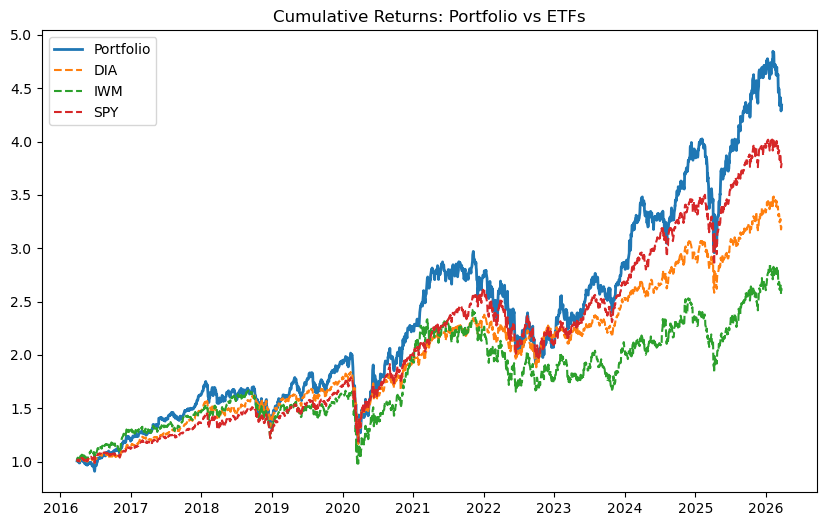

In [34]:
# portfolio vs ETFS - how portfolio performs versus SPY, IWM, and DIA
portfolio_cum = (1 + portfolio_returns).cumprod()

market_cum = (1 + market_index.pct_change()).cumprod()

plt.figure(figsize=(10,6))
plt.plot(portfolio_cum, label="Portfolio", linewidth=2)

for col in market_cum.columns:
    plt.plot(market_cum[col], label=col, linestyle="--")

plt.title("Cumulative Returns: Portfolio vs ETFs")
plt.legend()
plt.show()

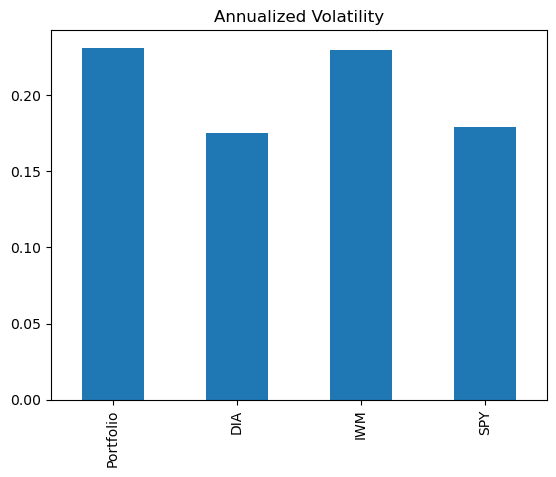

In [35]:
# portfolio risk vs ETFs - is the portfolio more or less volatile than SPY, IWM, and DIA?

vol_data = {
    "Portfolio": portfolio_returns.std() * np.sqrt(252),
}

for col in market_index.columns:
    vol_data[col] = market_index[col].pct_change().std() * np.sqrt(252)

pd.Series(vol_data).plot(kind="bar", title="Annualized Volatility")
plt.show()

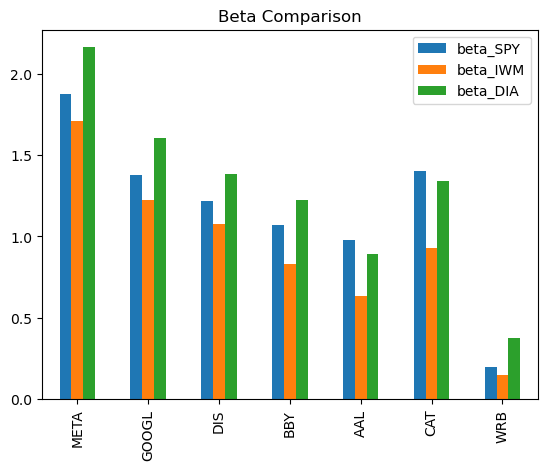

In [36]:
# beta comparision chart - aggressive vs defensive
stock_vs_market[["beta_SPY", "beta_IWM", "beta_DIA"]].plot(kind="bar")
plt.title("Beta Comparison")
plt.show()

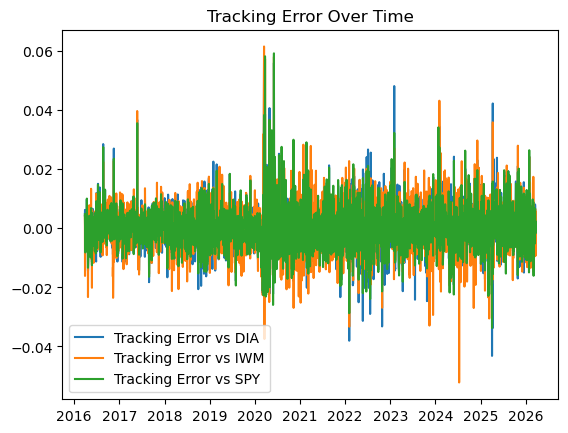

In [37]:
# tracking error visualization
for col in market_index.columns:
    diff = portfolio_returns - market_index[col].pct_change()
    plt.plot(diff, label=f"Tracking Error vs {col}")

plt.legend()
plt.title("Tracking Error Over Time")
plt.show()

## 3. Correlation Matrix

In [38]:
# convert to dataframe for easier calculations

# Source: pandas documentation — DataFrame.corr() computes the correlation matrix.
# Source: Matplotlib documentation/examples — imshow() can display matrix-style data as an image/heatmap.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

portfolio_returns_df = portfolio_returns.to_frame()

# part 3 -  Create a correlation matrix showing the correlations between the equal-weighted portfolio created from 
# your 7 assets, the 3 ETFs, and your 7 individual stocks

# Combine the portfolio, ETFs, and individual stocks into a single DataFrame
combined_data = pd.concat(
    [portfolio_returns_df, market_returns, stock_returns],
    axis=1
).dropna()

# Calculate the correlation matrix
correlation_matrix = combined_data.corr()

correlation_matrix

,Portfolio,DIA,IWM,SPY,META,GOOGL,DIS,BBY,AAL,CAT,WRB
Portfolio,1.000000,0.858872,0.836999,0.877304,0.729637,0.659697,0.687623,0.711175,0.671296,0.636616,0.542752
DIA,0.858872,1.000000,0.848810,0.945911,0.522538,0.541114,0.692592,0.641022,0.606004,0.489724,0.622773
IWM,0.836999,0.848810,1.000000,0.864727,0.564683,0.560069,0.665970,0.600362,0.556409,0.476253,0.517844
SPY,0.877304,0.945911,0.864727,1.000000,0.502142,0.543568,0.638988,0.628023,0.719475,0.613614,0.539110
META,0.729637,0.522538,0.564683,0.502142,1.000000,0.357821,0.422789,0.446587,0.300819,0.252990,0.316499
GOOGL,0.659697,0.541114,0.560069,0.543568,0.357821,1.000000,0.387863,0.390041,0.309737,0.297230,0.269851
DIS,0.687623,0.692592,0.665970,0.638988,0.422789,0.387863,1.000000,0.434066,0.375505,0.277475,0.406216
BBY,0.711175,0.641022,0.600362,0.628023,0.446587,0.390041,0.434066,1.000000,0.403366,0.362817,0.382982
AAL,0.671296,0.606004,0.556409,0.719475,0.300819,0.309737,0.375505,0.403366,1.000000,0.604889,0.247957
CAT,0.636616,0.489724,0.476253,0.613614,0.252990,0.297230,0.277475,0.362817,0.604889,1.000000,0.155890


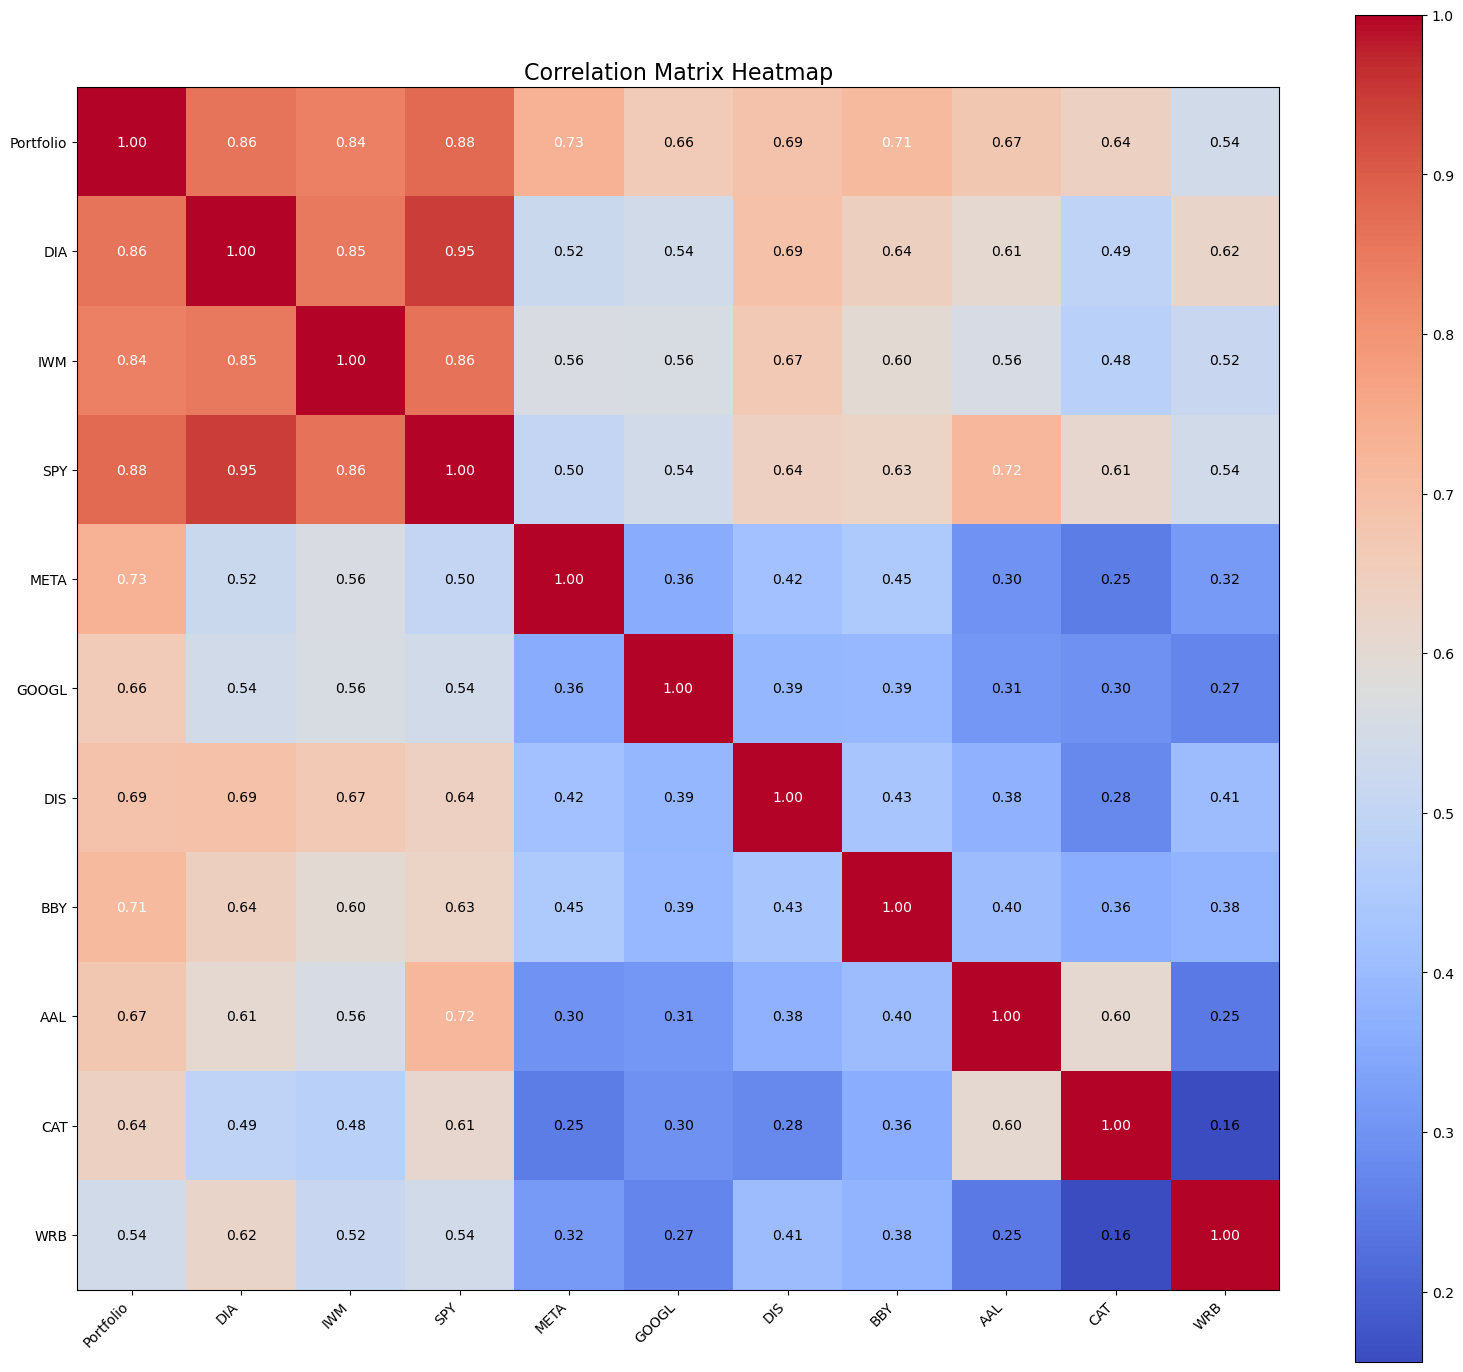

In [39]:
# correlation matrix heatmap

# Use your correlation matrix
corr = correlation_matrix.values
labels = correlation_matrix.columns

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap="coolwarm")

# Show all ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Loop over data dimensions and create text annotations manually
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        color = "white" if abs(corr[i, j]) > 0.7 else "black"
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color=color)

# Add colorbar
fig.colorbar(im)
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.tight_layout()
plt.show()